# Анализ акций Сбербанка (SBER)

## Exploratory Data Analysis (EDA)

Источник данных:
- MOEX ISS API

Актив:
- SBER (Сбербанк)

Цель:
- исследовать динамику цены
- подготовить признаки для ML-модели
- построить базовый прогноз направления движения цены

Автор: Гордеева Диана

In [ ]:
# Импорт библиотек

import pandas as pd # type: ignore
import numpy as np # type: ignore

import matplotlib.pyplot as plt # type: ignore

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Loading dataset

We load historical SBER stock data received from MOEX ISS API.

In [3]:
# Загрузка данных

DATA_PATH = Path("../data/raw/sber_stock_cache.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

df.head()

,date,open,close,high,low,value,volume
0,2020-01-03,255.99,255.00,258.19,253.70,9.165475e+09,35851840
1,2020-01-06,254.75,253.90,254.84,251.40,5.646010e+09,22348300
2,2020-01-08,253.57,259.15,259.15,253.03,1.048588e+10,40817240
3,2020-01-09,259.40,257.99,261.76,257.01,9.936032e+09,38329020
4,2020-01-10,257.86,258.19,259.25,256.88,4.864405e+09,18851390


In [4]:
# Размер датасета

df.shape

(100, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    100 non-null    datetime64[us]
 1   open    100 non-null    float64       
 2   close   100 non-null    float64       
 3   high    100 non-null    float64       
 4   low     100 non-null    float64       
 5   value   100 non-null    float64       
 6   volume  100 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 5.6 KB


In [6]:
df.describe()

,date,open,close,high,low,value,volume
count,100,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02
mean,2020-03-16 13:55:12,218.484300,218.181400,221.427400,215.059600,1.589716e+10,7.689312e+07
min,2020-01-03 00:00:00,175.000000,174.270000,182.200000,172.150000,4.393813e+09,1.885139e+07
25%,2020-02-09 06:00:00,190.290000,190.027500,192.537500,186.645000,1.007119e+10,4.076397e+07
50%,2020-03-17 12:00:00,198.965000,198.555000,202.800000,195.290000,1.335586e+10,6.249986e+07
75%,2020-04-21 06:00:00,253.912500,253.892500,255.257500,251.912500,1.999975e+10,9.911986e+07
max,2020-05-28 00:00:00,268.720000,268.060000,270.800000,265.500000,5.043423e+10,2.630383e+08
std,NaN,31.783153,31.654482,31.135507,32.330007,8.988344e+09,4.944748e+07


In [ ]:
import pandas as pd # type: ignore # type: ignore
import numpy as np

import matplotlib.pyplot as plt # type: ignore

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Environment ready ")

Environment ready 


In [9]:
DATA_PATH = Path("../data/raw/sber_stock_cache.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

df.head()

,date,open,close,high,low,value,volume
0,2020-01-03,255.99,255.00,258.19,253.70,9.165475e+09,35851840
1,2020-01-06,254.75,253.90,254.84,251.40,5.646010e+09,22348300
2,2020-01-08,253.57,259.15,259.15,253.03,1.048588e+10,40817240
3,2020-01-09,259.40,257.99,261.76,257.01,9.936032e+09,38329020
4,2020-01-10,257.86,258.19,259.25,256.88,4.864405e+09,18851390


In [10]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset shape:
(100, 7)

Columns:
['date', 'open', 'close', 'high', 'low', 'value', 'volume']


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    100 non-null    datetime64[us]
 1   open    100 non-null    float64       
 2   close   100 non-null    float64       
 3   high    100 non-null    float64       
 4   low     100 non-null    float64       
 5   value   100 non-null    float64       
 6   volume  100 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 5.6 KB


In [12]:
df.describe()

,date,open,close,high,low,value,volume
count,100,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02
mean,2020-03-16 13:55:12,218.484300,218.181400,221.427400,215.059600,1.589716e+10,7.689312e+07
min,2020-01-03 00:00:00,175.000000,174.270000,182.200000,172.150000,4.393813e+09,1.885139e+07
25%,2020-02-09 06:00:00,190.290000,190.027500,192.537500,186.645000,1.007119e+10,4.076397e+07
50%,2020-03-17 12:00:00,198.965000,198.555000,202.800000,195.290000,1.335586e+10,6.249986e+07
75%,2020-04-21 06:00:00,253.912500,253.892500,255.257500,251.912500,1.999975e+10,9.911986e+07
max,2020-05-28 00:00:00,268.720000,268.060000,270.800000,265.500000,5.043423e+10,2.630383e+08
std,NaN,31.783153,31.654482,31.135507,32.330007,8.988344e+09,4.944748e+07


In [13]:
# Проверка пропущенных значений

df.isna().sum()

date      0
open      0
close     0
high      0
low       0
value     0
volume    0
dtype: int64

In [14]:
# Проверка дубликатов

print(f"Количество дубликатов: {df.duplicated().sum()}")

Количество дубликатов: 0


In [15]:
# Проверка сортировки по дате

print(f"Данные отсортированы по дате: {df['date'].is_monotonic_increasing}")

Данные отсортированы по дате: True


In [16]:
# Временной диапазон

print(f"Начальная дата: {df['date'].min().date()}")
print(f"Конечная дата: {df['date'].max().date()}")

Начальная дата: 2020-01-03
Конечная дата: 2020-05-28


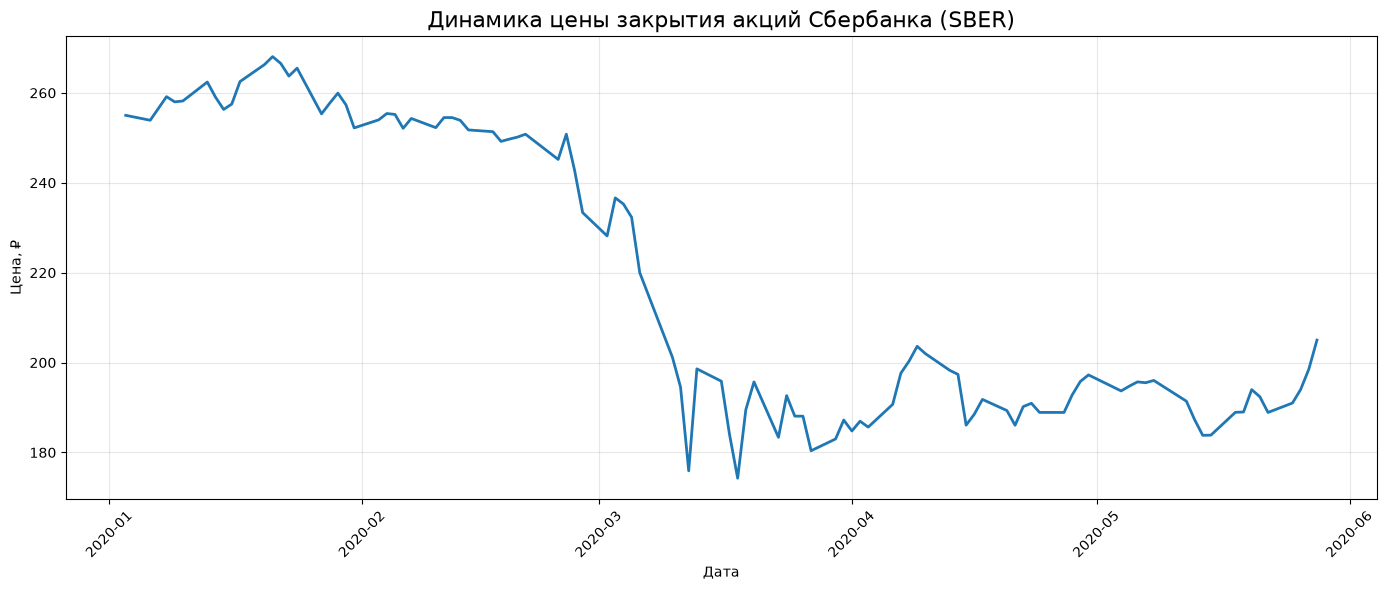

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["date"],
    df["close"],
    linewidth=2
)

plt.title(
    "Динамика цены закрытия акций Сбербанка (SBER)",
    fontsize=16
)

plt.xlabel("Дата")
plt.ylabel("Цена, ₽")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# Расчёт дневной доходности

df["return_1d"] = df["close"].pct_change()

df[["date", "close", "return_1d"]].head(10)

,date,close,return_1d
0,2020-01-03,255.00,NaN
1,2020-01-06,253.90,-0.004314
2,2020-01-08,259.15,0.020677
3,2020-01-09,257.99,-0.004476
4,2020-01-10,258.19,0.000775
5,2020-01-13,262.40,0.016306
6,2020-01-14,259.05,-0.012767
7,2020-01-15,256.31,-0.010577
8,2020-01-16,257.51,0.004682
9,2020-01-17,262.50,0.019378


In [19]:
# Статистика дневной доходности

df["return_1d"].describe().round(4)

count    99.0000
mean     -0.0018
std       0.0297
min      -0.0957
25%      -0.0130
50%      -0.0001
75%       0.0133
max       0.1290
Name: return_1d, dtype: float64

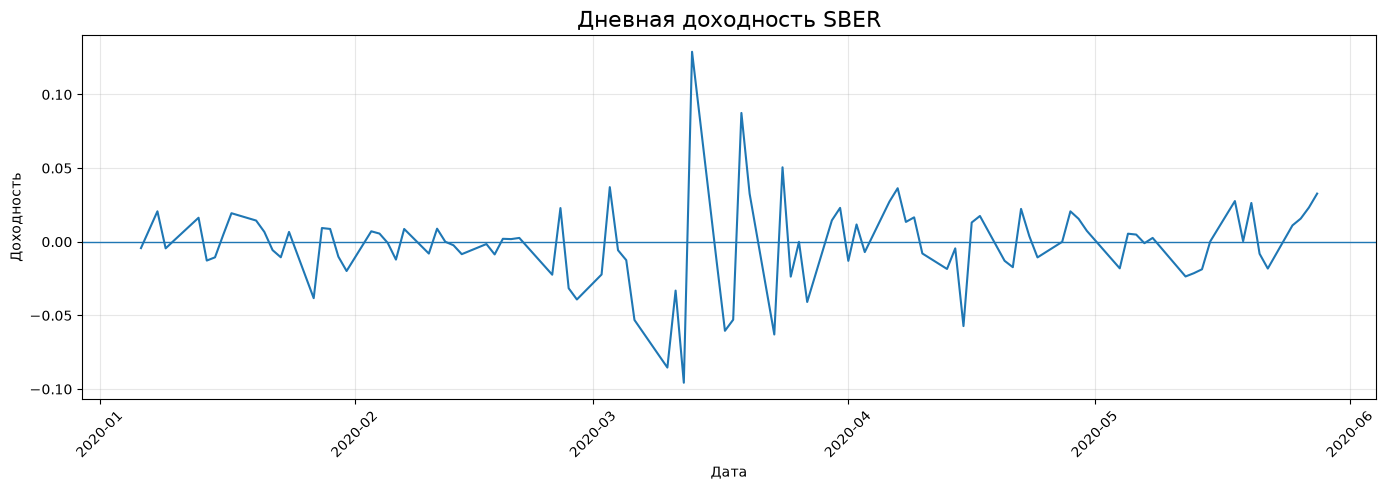

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["return_1d"],
    linewidth=1.5
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Дневная доходность SBER",
    fontsize=16
)

plt.xlabel("Дата")
plt.ylabel("Доходность")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Расчёт 7-дневной скользящей волатильности

df["volatility_7d"] = (
    df["return_1d"]
    .rolling(window=7)
    .std()
)

df[["date", "return_1d", "volatility_7d"]].tail(10)

,date,return_1d,volatility_7d
90,2020-05-15,0.000218,0.012453
91,2020-05-18,0.027631,0.018102
92,2020-05-19,0.000371,0.018157
93,2020-05-20,0.026349,0.021631
94,2020-05-21,-0.008145,0.019682
95,2020-05-22,-0.018191,0.019111
96,2020-05-25,0.011117,0.017115
97,2020-05-26,0.015707,0.017301
98,2020-05-27,0.023247,0.016527
99,2020-05-28,0.032694,0.018674


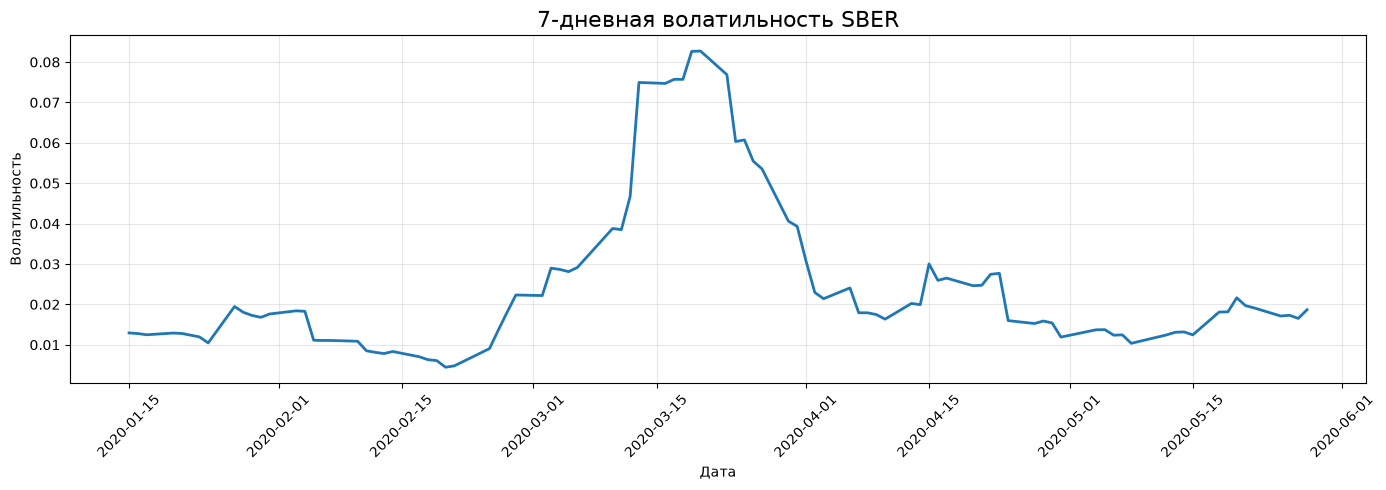

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["volatility_7d"],
    linewidth=2
)

plt.title(
    "7-дневная волатильность SBER",
    fontsize=16
)

plt.xlabel("Дата")
plt.ylabel("Волатильность")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Feature Engineering

Создадим признаки на основе исторических данных.

Скользящие средние помогут модели учитывать краткосрочный и среднесрочный тренд цены.

In [24]:
# Скользящие средние

df["ma_7"] = df["close"].rolling(window=7).mean()
df["ma_30"] = df["close"].rolling(window=30).mean()

df[["date", "close", "ma_7", "ma_30"]].tail(10)

,date,close,ma_7,ma_30
90,2020-05-15,183.85,190.514286,192.367333
91,2020-05-18,188.93,189.547143,192.433333
92,2020-05-19,189.00,188.617143,192.545333
93,2020-05-20,193.98,188.325714,192.654667
94,2020-05-21,192.40,188.468571,192.480333
95,2020-05-22,188.90,188.695714,192.100667
96,2020-05-25,191.00,189.722857,191.680333
97,2020-05-26,194.00,191.172857,191.414000
98,2020-05-27,198.51,192.541429,191.422333
99,2020-05-28,205.00,194.827143,191.676667


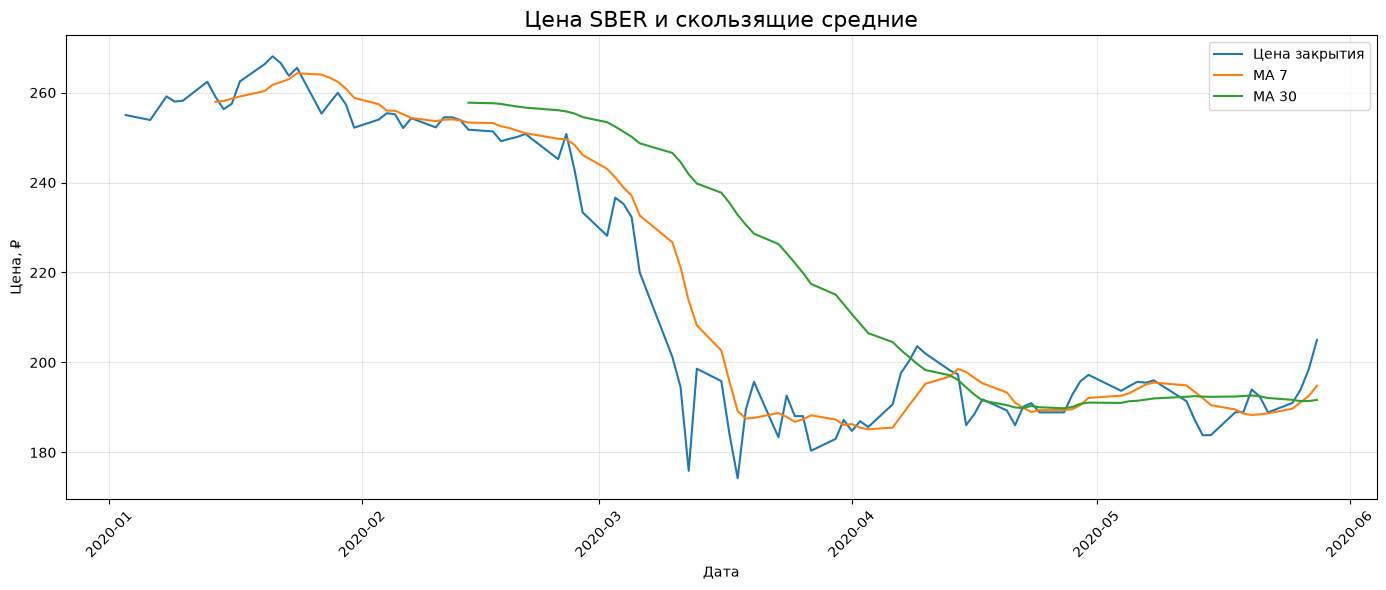

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["date"],
    df["close"],
    label="Цена закрытия"
)

plt.plot(
    df["date"],
    df["ma_7"],
    label="MA 7"
)

plt.plot(
    df["date"],
    df["ma_30"],
    label="MA 30"
)

plt.title(
    "Цена SBER и скользящие средние",
    fontsize=16
)

plt.xlabel("Дата")
plt.ylabel("Цена, ₽")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Изменение объема торгов

df["volume_change"] = df["volume"].pct_change()

df[["date", "volume", "volume_change"]].tail(10)

,date,volume,volume_change
90,2020-05-15,63148140,-0.176495
91,2020-05-18,77545890,0.228000
92,2020-05-19,105324020,0.358215
93,2020-05-20,93343040,-0.113754
94,2020-05-21,79541950,-0.147853
95,2020-05-22,57013570,-0.283226
96,2020-05-25,23140090,-0.594130
97,2020-05-26,79312200,2.427480
98,2020-05-27,116074210,0.463510
99,2020-05-28,117179670,0.009524


In [28]:
# Дневной диапазон цены

df["price_range"] = (
    df["high"] - df["low"]
)

df[["date", "high", "low", "price_range"]].tail(10)

,date,high,low,price_range
90,2020-05-15,186.78,183.33,3.45
91,2020-05-18,190.00,185.40,4.60
92,2020-05-19,192.55,186.80,5.75
93,2020-05-20,193.98,186.60,7.38
94,2020-05-21,196.31,191.50,4.81
95,2020-05-22,191.25,188.60,2.65
96,2020-05-25,191.31,188.80,2.51
97,2020-05-26,196.10,192.11,3.99
98,2020-05-27,198.97,193.32,5.65
99,2020-05-28,205.00,198.40,6.60


In [29]:
# Относительный диапазон

df["price_range_pct"] = (
    (df["high"] - df["low"]) / df["close"]
)

df[
    ["date", "close", "price_range_pct"]
].tail(10)

,date,close,price_range_pct
90,2020-05-15,183.85,0.018765
91,2020-05-18,188.93,0.024348
92,2020-05-19,189.00,0.030423
93,2020-05-20,193.98,0.038045
94,2020-05-21,192.40,0.025000
95,2020-05-22,188.90,0.014029
96,2020-05-25,191.00,0.013141
97,2020-05-26,194.00,0.020567
98,2020-05-27,198.51,0.028462
99,2020-05-28,205.00,0.032195


In [31]:
# Target

df["target"] = (
    df["close"].shift(-1) > df["close"]
).astype(int)

df[
    ["date", "close", "target"]
].tail(10)

,date,close,target
90,2020-05-15,183.85,1
91,2020-05-18,188.93,1
92,2020-05-19,189.00,1
93,2020-05-20,193.98,0
94,2020-05-21,192.40,0
95,2020-05-22,188.90,1
96,2020-05-25,191.00,1
97,2020-05-26,194.00,1
98,2020-05-27,198.51,1
99,2020-05-28,205.00,0


In [33]:
# Баланс классов

target_distribution = df["target"].value_counts()

target_distribution

target
0    52
1    48
Name: count, dtype: int64

In [34]:
# Баланс классов в %

target_distribution_pct = (
    df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution_pct


target
0    52.0
1    48.0
Name: proportion, dtype: float64

In [35]:
# Финал. набор признаков

features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_7d",
    "ma_7",
    "ma_30",
    "volume_change",
    "price_range",
    "price_range_pct"
]

X = df[features]
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)


Features: (100, 12)
Target: (100,)


In [36]:
# Чистка

model_df = df[
    features + ["target"]
].dropna().copy()

print(f"Строк до очистки: {len(df)}")
print(f"Строк для модели: {len(model_df)}")


Строк до очистки: 100
Строк для модели: 71


In [37]:
model_df.isna().sum()

open               0
high               0
low                0
close              0
volume             0
return_1d          0
volatility_7d      0
ma_7               0
ma_30              0
volume_change      0
price_range        0
price_range_pct    0
target             0
dtype: int64

## 9. Time Series Train/Test Split

Для временного ряда нельзя случайным образом перемешивать наблюдения.

Модель обучается на прошлом и проверяется на будущем.

In [4]:
# Загрузка данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_PATH = Path("../data/raw/sber_stock_cache.csv")

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Размер данных: {df.shape}")
print(
    f"Период: "
    f"{df['date'].min().date()} → "
    f"{df['date'].max().date()}"
)

df.head()

Размер данных: (1799, 7)
Период: 2020-01-03 → 2026-09-10


,date,open,close,high,low,value,volume
0,2020-01-03,255.99,255.00,258.19,253.70,9.165475e+09,35851840
1,2020-01-06,254.75,253.90,254.84,251.40,5.646010e+09,22348300
2,2020-01-08,253.57,259.15,259.15,253.03,1.048588e+10,40817240
3,2020-01-09,259.40,257.99,261.76,257.01,9.936032e+09,38329020
4,2020-01-10,257.86,258.19,259.25,256.88,4.864405e+09,18851390


In [8]:
# Подготовка данных для ML

df = df.sort_values("date").reset_index(drop=True)

# Дневная доходность
df["return_1d"] = df["close"].pct_change()

# 7-дневная волатильность
df["volatility_7d"] = (
    df["return_1d"]
    .rolling(window=7)
    .std()
)

# Скользящие средние
df["ma_7"] = (
    df["close"]
    .rolling(window=7)
    .mean()
)

df["ma_30"] = (
    df["close"]
    .rolling(window=30)
    .mean()
)

# Изменение объёма
df["volume_change"] = (
    df["volume"]
    .pct_change()
)

# Дневной диапазон цены
df["price_range"] = (
    df["high"] - df["low"]
)

# Относительный диапазон
df["price_range_pct"] = (
    (df["high"] - df["low"])
    / df["close"]
)

# Target:
# 1 — цена следующего торгового дня выше текущей
# 0 — цена следующего торгового дня не выше текущей

next_close = df["close"].shift(-1)

df["target"] = np.where(
    next_close.isna(),
    np.nan,
    (next_close > df["close"]).astype(int)
)

df[["date", "close", "target"]].tail()


# Список признаков
features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_7d",
    "ma_7",
    "ma_30",
    "volume_change",
    "price_range",
    "price_range_pct",
]


# Финальный датасет
model_df = (
    df[["date"] + features + ["target"]]
    .dropna()
    .copy()
)

model_df = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Исходных строк: {len(df)}")
print(f"Строк для модели: {len(model_df)}")
print(f"Количество признаков: {len(features)}")

Исходных строк: 1799
Строк для модели: 1769
Количество признаков: 12


In [9]:
model_df.isna().sum()


date               0
open               0
high               0
low                0
close              0
volume             0
return_1d          0
volatility_7d      0
ma_7               0
ma_30              0
volume_change      0
price_range        0
price_range_pct    0
target             0
dtype: int64

In [10]:
model_df.head()

,date,open,high,low,close,volume,return_1d,volatility_7d,ma_7,ma_30,volume_change,price_range,price_range_pct,target
0,2020-02-14,254.40,254.40,251.40,251.75,30017380,-0.008429,0.008331,253.330000,257.749000,-0.182774,3.00,0.011917,0.0
1,2020-02-17,252.50,253.10,250.13,251.36,26429380,-0.001549,0.007032,253.222857,257.627667,-0.119531,2.97,0.011816,0.0
2,2020-02-18,250.07,250.44,247.57,249.20,36365950,-0.008593,0.006304,252.494286,257.471000,0.375967,2.87,0.011517,1.0
3,2020-02-19,250.37,250.68,247.95,249.70,25798890,0.002006,0.006074,252.128571,257.156000,-0.290576,2.73,0.010933,1.0
4,2020-02-20,250.03,252.17,249.13,250.15,30717360,0.001802,0.004439,251.507143,256.894667,0.190647,3.04,0.012153,1.0


## 10. Финальный датасет для машинного обучения

На основе рассчитанных признаков сформируем итоговый датасет.

Удалим строки, для которых невозможно рассчитать признаки или целевую переменную.

In [11]:
# Признаки для ML-модели

features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_7d",
    "ma_7",
    "ma_30",
    "volume_change",
    "price_range",
    "price_range_pct",
]

# Формирование финального датасета

model_df = (
    df[["date"] + features + ["target"]]
    .dropna()
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Исходных строк: {len(df)}")
print(f"Строк для ML: {len(model_df)}")
print(f"Количество признаков: {len(features)}")

Исходных строк: 1799
Строк для ML: 1769
Количество признаков: 12


In [12]:
model_df.isna().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
return_1d          0
volatility_7d      0
ma_7               0
ma_30              0
volume_change      0
price_range        0
price_range_pct    0
target             0
dtype: int64

In [14]:
# Проверка Target

print(model_df["target"].value_counts())

print("\nДоли классов:")
print(
    model_df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


target
1.0    918
0.0    851
Name: count, dtype: int64

Доли классов:
target
1.0    51.89
0.0    48.11
Name: proportion, dtype: float64


In [3]:
from pathlib import Path

PROCESSED_PATH = Path("../data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_PATH / "sber_features.csv"

model_df.to_csv(OUTPUT_FILE, index=False)

print(f"Saved: {OUTPUT_FILE}")
print(f"Rows: {len(model_df)}")
print(f"Columns: {len(model_df.columns)}")

NameError: name 'model_df' is not defined

In [15]:
model_df.head()

,date,open,high,low,close,volume,return_1d,volatility_7d,ma_7,ma_30,volume_change,price_range,price_range_pct,target
0,2020-02-14,254.40,254.40,251.40,251.75,30017380,-0.008429,0.008331,253.330000,257.749000,-0.182774,3.00,0.011917,0.0
1,2020-02-17,252.50,253.10,250.13,251.36,26429380,-0.001549,0.007032,253.222857,257.627667,-0.119531,2.97,0.011816,0.0
2,2020-02-18,250.07,250.44,247.57,249.20,36365950,-0.008593,0.006304,252.494286,257.471000,0.375967,2.87,0.011517,1.0
3,2020-02-19,250.37,250.68,247.95,249.70,25798890,0.002006,0.006074,252.128571,257.156000,-0.290576,2.73,0.010933,1.0
4,2020-02-20,250.03,252.17,249.13,250.15,30717360,0.001802,0.004439,251.507143,256.894667,0.190647,3.04,0.012153,1.0


In [16]:
model_df.tail()

,date,open,high,low,close,volume,return_1d,volatility_7d,ma_7,ma_30,volume_change,price_range,price_range_pct,target
1764,2026-09-05,281.00,282.00,279.69,281.02,3258625,0.001211,0.012520,275.997143,276.270333,-0.881928,2.31,0.008220,0.0
1765,2026-09-06,280.90,281.01,276.60,277.10,5141983,-0.013949,0.014715,277.170000,275.917333,0.577961,4.41,0.015915,1.0
1766,2026-09-07,277.10,280.70,277.09,280.08,12364334,0.010754,0.011869,277.774286,275.761667,1.404585,3.61,0.012889,0.0
1767,2026-09-08,280.33,281.74,277.16,279.20,23673870,-0.003142,0.010178,278.772857,275.651667,0.914690,4.58,0.016404,0.0
1768,2026-09-09,278.95,279.98,275.50,277.04,19889950,-0.007736,0.010821,279.167143,275.431333,-0.159835,4.48,0.016171,1.0


## 11. Time Series Train/Test Split

Поскольку данные являются временным рядом, разделение на обучающую и тестовую выборки выполняется хронологически.

Модель обучается на исторических данных и проверяется на более позднем периоде.

Перемешивание (`shuffle`) не используется, чтобы избежать утечки информации из будущего.

In [17]:
# Разделение данных по времени

split_date = model_df["date"].quantile(0.8)

train_df = model_df[model_df["date"] < split_date].copy()
test_df = model_df[model_df["date"] >= split_date].copy()

print(f"Дата разделения: {split_date.date()}")
print(f"Train: {len(train_df)} строк")
print(f"Test:  {len(test_df)} строк")

print("\nПериод Train:")
print(train_df["date"].min().date(), "→", train_df["date"].max().date())

print("\nПериод Test:")
print(test_df["date"].min().date(), "→", test_df["date"].max().date())

Дата разделения: 2025-08-19
Train: 1415 строк
Test:  354 строк

Период Train:
2020-02-14 → 2025-08-19

Период Test:
2025-08-20 → 2026-09-09


In [18]:
# Корректность временной последовательности

assert train_df["date"].max() < test_df["date"].min()

print("Временная последовательность корректна.")

Временная последовательность корректна.


In [19]:
X_train = train_df[features]
y_train = train_df["target"]

X_test = test_df[features]
y_test = test_df["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1415, 12)
y_train: (1415,)
X_test: (354, 12)
y_test: (354,)


In [20]:
# Распределение классов

print("Train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index())


Train:
target
0.0    0.479152
1.0    0.520848
Name: proportion, dtype: float64

Test:
target
0.0    0.488701
1.0    0.511299
Name: proportion, dtype: float64


## 12. Baseline Model

В качестве baseline используем простое правило: модель всегда предсказывает наиболее частый класс в обучающей выборке.

Baseline необходим, чтобы понять, действительно ли машинное обучение даёт улучшение относительно элементарной стратегии.

In [21]:
from sklearn.metrics import accuracy_score

# Самый частый класс в обучающей выборке
baseline_class = y_train.mode()[0]

# Предсказываем этот класс для всех тестовых наблюдений
baseline_pred = np.full(
    shape=len(y_test),
    fill_value=baseline_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(f"Baseline class: {baseline_class}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline class: 1.0
Baseline accuracy: 0.5113


## 13. Logistic Regression

В качестве первой ML-модели используется Logistic Regression.

Модель решает задачу бинарной классификации:

- `1` — цена следующего торгового дня выросла;
- `0` — цена следующего торгового дня не выросла.

Перед обучением числовые признаки масштабируются с помощью `StandardScaler`.

Scaler обучается только на обучающей выборке, чтобы избежать data leakage.

In [ ]:
# Импорты

from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

In [23]:
# Масштабирование данных

# Создаём scaler только на Train

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (1415, 12)
X_test_scaled: (354, 12)


In [24]:
# Обучение Logistic Regression

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

print("Logistic Regression обучена.")

Logistic Regression обучена.


In [25]:
# Прогноз

logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Первые 10 предсказаний:")
print(logreg_pred[:10])

Первые 10 предсказаний:
[1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


### Оценка качества Logistic Regression

In [26]:
logreg_accuracy = accuracy_score(y_test, logreg_pred)
logreg_precision = precision_score(y_test, logreg_pred)
logreg_recall = recall_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred)
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)

print(f"Accuracy:  {logreg_accuracy:.4f}")
print(f"Precision: {logreg_precision:.4f}")
print(f"Recall:    {logreg_recall:.4f}")
print(f"F1-score:  {logreg_f1:.4f}")
print(f"ROC-AUC:   {logreg_roc_auc:.4f}")

Accuracy:  0.5282
Precision: 0.5240
Recall:    0.8453
F1-score:  0.6469
ROC-AUC:   0.5681


In [27]:
# Полный Classification Report

print(
    classification_report(
        y_test,
        logreg_pred,
        target_names=["DOWN / 0", "UP / 1"]
    )
)

              precision    recall  f1-score   support

    DOWN / 0       0.55      0.20      0.29       173
      UP / 1       0.52      0.85      0.65       181

    accuracy                           0.53       354
   macro avg       0.54      0.52      0.47       354
weighted avg       0.54      0.53      0.47       354



## 13.1 Матрица ошибок

### Confusion Matrix

Матрица ошибок показывает количество правильных и неправильных предсказаний для каждого класса.

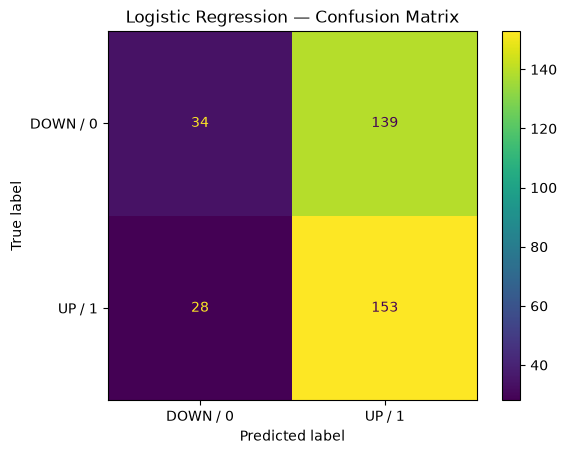

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_pred,
    display_labels=["DOWN / 0", "UP / 1"]
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## 13.2 Коэффициенты модели

In [29]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": logreg.coef_[0]
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()

coefficients = (
    coefficients
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

coefficients

,feature,coefficient,abs_coefficient
0,close,-0.509289,0.509289
1,high,0.418242,0.418242
2,low,0.418088,0.418088
3,ma_7,-0.299554,0.299554
4,open,-0.274795,0.274795
5,volatility_7d,-0.147808,0.147808
6,return_1d,-0.144936,0.144936
7,ma_30,0.096503,0.096503
8,price_range_pct,-0.057890,0.057890
9,volume,0.039135,0.039135


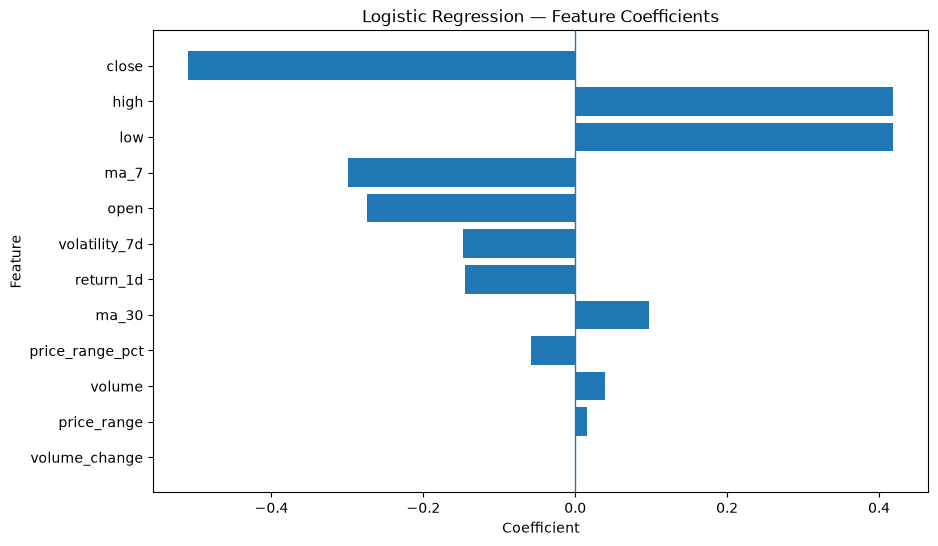

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["feature"],
    coefficients["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression — Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [31]:
# Сравнение с Baseline

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        logreg_accuracy
    ],
    "Precision": [
        np.nan,
        logreg_precision
    ],
    "Recall": [
        np.nan,
        logreg_recall
    ],
    "F1": [
        np.nan,
        logreg_f1
    ],
    "ROC-AUC": [
        np.nan,
        logreg_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.511299,NaN,NaN,NaN,NaN
1,Logistic Regression,0.528249,0.523973,0.845304,0.646934,0.568103


## 14. Random Forest

Второй ML-подход — Random Forest.

В отличие от Logistic Regression, Random Forest способен моделировать нелинейные зависимости между признаками.

Модель обучается только на исторической части данных и оценивается на отложенной тестовой выборке.

In [32]:
# Импорт

from sklearn.ensemble import RandomForestClassifier


In [34]:
# Обучение 

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest обучена.")

Random Forest обучена.


In [35]:
# Прогноз

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Первые 10 предсказаний:")
print(rf_pred[:10])

Первые 10 предсказаний:
[0. 1. 1. 0. 0. 1. 1. 1. 1. 1.]


### Оценка качества Random Forest

In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.5339
Precision: 0.5396
Recall:    0.6022
F1-score:  0.5692
ROC-AUC:   0.5445


In [37]:
# Classification Report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["DOWN / 0", "UP / 1"]
    )
)

              precision    recall  f1-score   support

    DOWN / 0       0.53      0.46      0.49       173
      UP / 1       0.54      0.60      0.57       181

    accuracy                           0.53       354
   macro avg       0.53      0.53      0.53       354
weighted avg       0.53      0.53      0.53       354



## 14.1 Confusion Matrix

### Confusion Matrix — Random Forest

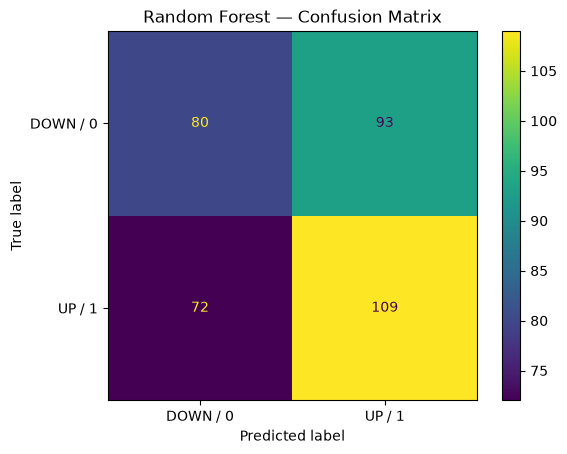

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["DOWN / 0", "UP / 1"]
)

plt.title("Random Forest — Confusion Matrix")
plt.show()

## 14.2 Feature Importance

In [39]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_importance

,feature,importance
0,return_1d,0.134369
1,volume_change,0.097010
2,volatility_7d,0.094212
3,price_range_pct,0.090787
4,volume,0.085769
5,ma_7,0.079742
6,price_range,0.077153
7,ma_30,0.074476
8,close,0.067805
9,low,0.067568


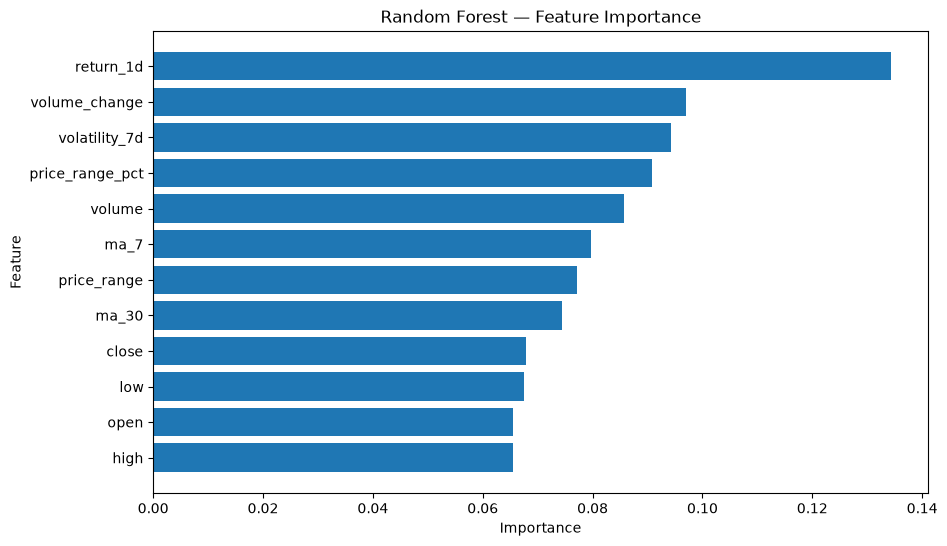

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["feature"],
    rf_importance["importance"]
)

plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## 14.3 Сравнение всех моделей

### Обновление таблицы

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logreg_accuracy,
        rf_accuracy
    ],
    "Precision": [
        np.nan,
        logreg_precision,
        rf_precision
    ],
    "Recall": [
        np.nan,
        logreg_recall,
        rf_recall
    ],
    "F1": [
        np.nan,
        logreg_f1,
        rf_f1
    ],
    "ROC-AUC": [
        np.nan,
        logreg_roc_auc,
        rf_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.511299,NaN,NaN,NaN,NaN
1,Logistic Regression,0.528249,0.523973,0.845304,0.646934,0.568103
2,Random Forest,0.533898,0.539604,0.602210,0.569191,0.544502


In [43]:
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.5113,NaN,NaN,NaN,NaN
1,Logistic Regression,0.5282,0.5240,0.8453,0.6469,0.5681
2,Random Forest,0.5339,0.5396,0.6022,0.5692,0.5445


## 14.4 Визуальное сравнение Accuracy

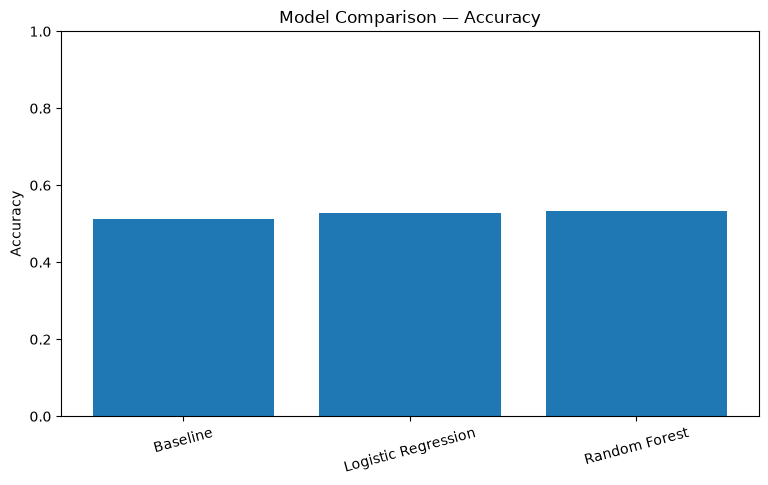

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Comparison — Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

## 14.5 Визуальное сравнение ROC-AUC

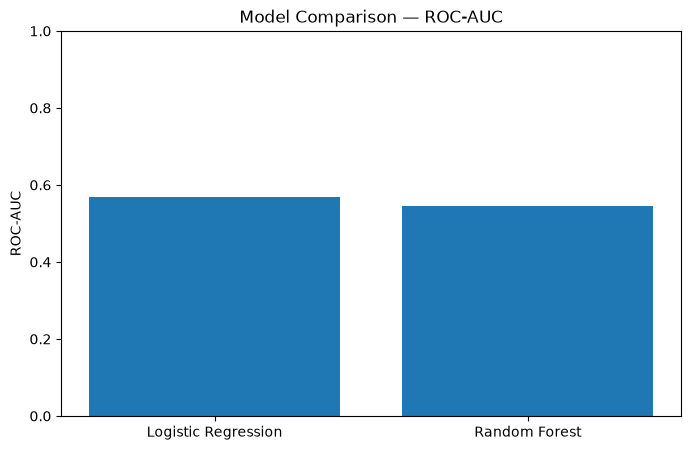

In [47]:
roc_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        logreg_roc_auc,
        rf_roc_auc
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    roc_comparison["Model"],
    roc_comparison["ROC-AUC"]
)

plt.title("Model Comparison — ROC-AUC")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)

plt.show()

## 15. ROC Curve

ROC-кривая позволяет сравнить способность моделей различать два класса:

- `0` — снижение или отсутствие роста цены;
- `1` — рост цены на следующий торговый день.

Для сравнения используются вероятностные прогнозы моделей.

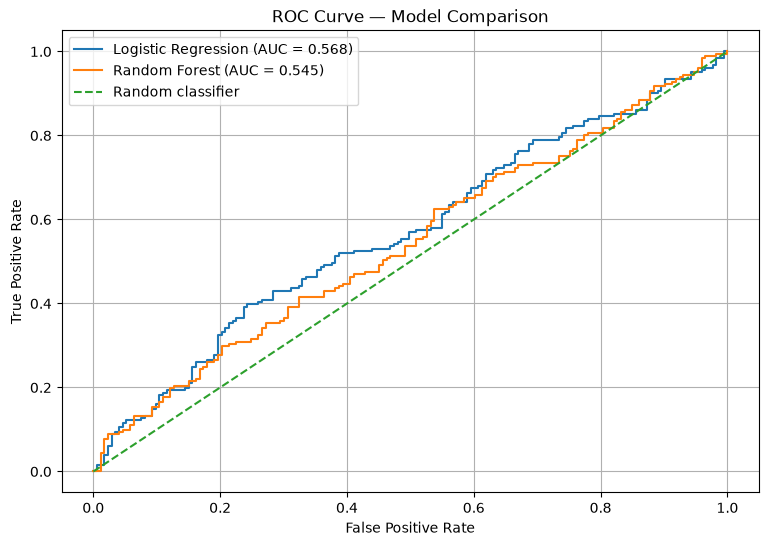

In [48]:
from sklearn.metrics import roc_curve

# ROC для Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(
    y_test,
    logreg_proba
)

# ROC для Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_proba
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logreg,
    tpr_logreg,
    label=f"Logistic Regression (AUC = {logreg_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curve — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

### 15.1 Финальное сравнение моделей

In [50]:
comparison = comparison.sort_values(
    "ROC-AUC",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5282,0.5240,0.8453,0.6469,0.5681
1,Random Forest,0.5339,0.5396,0.6022,0.5692,0.5445
2,Baseline,0.5113,NaN,NaN,NaN,NaN


In [51]:
# Определение лучшей модели

best_model = comparison.dropna(
    subset=["ROC-AUC"]
).iloc[0]["Model"]

best_roc_auc = comparison.dropna(
    subset=["ROC-AUC"]
).iloc[0]["ROC-AUC"]

print(f"Лучшая модель по ROC-AUC: {best_model}")
print(f"ROC-AUC: {best_roc_auc:.4f}")

Лучшая модель по ROC-AUC: Logistic Regression
ROC-AUC: 0.5681


## 16. Backtesting

На этом этапе проверяется простая стратегия на основе прогнозов модели.

Правило стратегии:

- если модель прогнозирует `1` — занимаем длинную позицию (`LONG`);
- если модель прогнозирует `0` — остаёмся вне позиции.

Доходность стратегии сравнивается с доходностью стратегии Buy & Hold.


Backtesting выполняется только на тестовом периоде.

In [52]:
# Подготовка тестового датасета

backtest = test_df[
    ["date", "close", "target"]
].copy()

backtest["prediction_logreg"] = logreg_pred
backtest["prediction_rf"] = rf_pred

backtest.head()

,date,close,target,prediction_logreg,prediction_rf
1415,2025-08-20,314.17,0.0,1.0,0.0
1416,2025-08-21,309.98,1.0,1.0,1.0
1417,2025-08-22,312.05,1.0,0.0,1.0
1418,2025-08-23,312.30,0.0,1.0,0.0
1419,2025-08-24,311.84,0.0,1.0,0.0


### 16.1 Доходность акции

In [54]:
backtest["market_return"] = (
    backtest["close"].pct_change()
)

backtest.head()

,date,close,target,prediction_logreg,prediction_rf,market_return
1415,2025-08-20,314.17,0.0,1.0,0.0,NaN
1416,2025-08-21,309.98,1.0,1.0,1.0,-0.013337
1417,2025-08-22,312.05,1.0,0.0,1.0,0.006678
1418,2025-08-23,312.30,0.0,1.0,0.0,0.000801
1419,2025-08-24,311.84,0.0,1.0,0.0,-0.001473


### 16.2 Стратегия Logistic Regression

In [55]:
backtest["strategy_logreg"] = (
    backtest["prediction_logreg"].shift(1)
    * backtest["market_return"]
)

### 16.3 Стратегия Random Forest

In [57]:
backtest["strategy_rf"] = (
    backtest["prediction_rf"].shift(1)
    * backtest["market_return"]
)

### 16.4 Buy & Hold

In [58]:
backtest["buy_hold"] = backtest["market_return"]

### 16.5 Кумулятивная доходность

In [61]:
# Изменение условного капитала

backtest["equity_logreg"] = (
    1 + backtest["strategy_logreg"].fillna(0)
).cumprod()

backtest["equity_rf"] = (
    1 + backtest["strategy_rf"].fillna(0)
).cumprod()

backtest["equity_buy_hold"] = (
    1 + backtest["buy_hold"].fillna(0)
).cumprod()

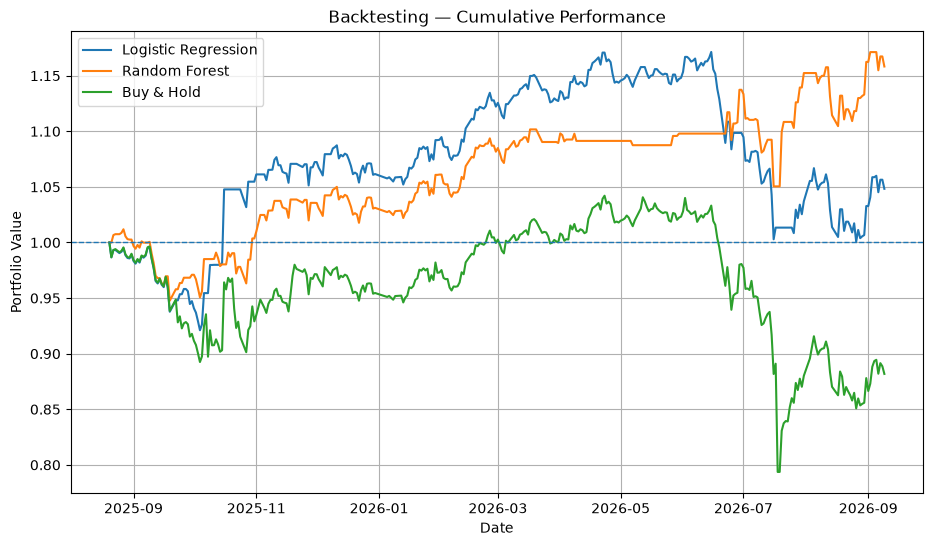

In [62]:
plt.figure(figsize=(11, 6))

plt.plot(
    backtest["date"],
    backtest["equity_logreg"],
    label="Logistic Regression"
)

plt.plot(
    backtest["date"],
    backtest["equity_rf"],
    label="Random Forest"
)

plt.plot(
    backtest["date"],
    backtest["equity_buy_hold"],
    label="Buy & Hold"
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.title("Backtesting — Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

### 16.6 Итоговая доходность

In [63]:
final_logreg = backtest["equity_logreg"].iloc[-1]
final_rf = backtest["equity_rf"].iloc[-1]
final_buy_hold = backtest["equity_buy_hold"].iloc[-1]

print(
    f"Logistic Regression: "
    f"{(final_logreg - 1) * 100:.2f}%"
)

print(
    f"Random Forest: "
    f"{(final_rf - 1) * 100:.2f}%"
)

print(
    f"Buy & Hold: "
    f"{(final_buy_hold - 1) * 100:.2f}%"
)

Logistic Regression: 4.83%
Random Forest: 15.83%
Buy & Hold: -11.82%


In [ ]:
### 16.7 Максимальная просадка

In [ ]:
def max_drawdown(equity):
    peak = equity.cummax()
    drawdown = equity / peak - 1
    return drawdown.min()

In [ ]:
print(
    f"Logistic Regression Max Drawdown: "
    f"{max_drawdown(backtest['equity_logreg']) * 100:.2f}%"
)

print(
    f"Random Forest Max Drawdown: "
    f"{max_drawdown(backtest['equity_rf']) * 100:.2f}%"
)

print(
    f"Buy & Hold Max Drawdown: "
    f"{max_drawdown(backtest['equity_buy_hold']) * 100:.2f}%"
)

In [ ]:
backtest_summary = pd.DataFrame({
    "Strategy": [
        "Logistic Regression",
        "Random Forest",
        "Buy & Hold"
    ],
    "Total Return": [
        final_logreg - 1,
        final_rf - 1,
        final_buy_hold - 1
    ],
    "Max Drawdown": [
        max_drawdown(backtest["equity_logreg"]),
        max_drawdown(backtest["equity_rf"]),
        max_drawdown(backtest["equity_buy_hold"])
    ]
})

backtest_summary[
    ["Total Return", "Max Drawdown"]
] = (
    backtest_summary[
        ["Total Return", "Max Drawdown"]
    ] * 100
)

backtest_summary.round(2)

## 17. Final Conclusions
В проекте были проанализированы исторические данные акций Сбера за 2020–2026 годы.

Были рассчитаны основные показатели и технические признаки, после чего обучены две модели для прогнозирования направления движения цены на следующий торговый день: Logistic Regression и Random Forest.

Модели сравнивались с простым baseline по основным метрикам качества и результатам backtesting.

## Что можно улучшить
В дальнейшем можно добавить больше признаков, попробовать другие модели, использовать walk-forward validation и учесть комиссии и проскальзывание при backtesting.

Результаты проекта носят исследовательский характер и не являются инвестиционной рекомендацией.